In [1]:
import os
import sys
import pysvzerod
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
os.chdir("/Users/kmbornemann/heart_valves/pressure_curves/svzerod_tune_preop")

In [3]:
p_lv_inlet = np.loadtxt("pressure_lv_inlet.csv", delimiter=",", skiprows=1)
p_lv_outlet = np.loadtxt("pressure_vsd.csv", delimiter=",", skiprows=1)

p_rv_inlet = np.loadtxt("pressure_rv_inlet.csv", delimiter=",", skiprows=1)
p_rv_outlet = np.loadtxt("pressure_vsd.csv", delimiter=",", skiprows=1)

p_truncus_upstream_inlet = np.loadtxt("pressure_vsd.csv", delimiter=",", skiprows=1)
p_truncus_upstream_outlet = np.loadtxt("pressure_up_valve.csv", delimiter=",", skiprows=1)

p_truncus_downstream_inlet = np.loadtxt("pressure_down_valve.csv", delimiter=",", skiprows=1)
p_truncus_downstream_outlet = np.loadtxt("pressure_aorta_inlet.csv", delimiter=",", skiprows=1)

p_valve_sys_inlet = np.loadtxt("pressure_up_valve.csv", delimiter=",", skiprows=1)
p_valve_sys_outlet = np.loadtxt("pressure_down_valve.csv", delimiter=",", skiprows=1)

p_valve_dia_inlet = np.loadtxt("pressure_up_valve.csv", delimiter=",", skiprows=1)
p_valve_dia_outlet = np.loadtxt("pressure_down_valve.csv", delimiter=",", skiprows=1)

p_aorta_inlet = np.loadtxt("pressure_aorta_inlet.csv", delimiter=",", skiprows=1)
p_aorta_outlet = np.loadtxt("pressure_aorta_outlet.csv", delimiter=",", skiprows=1)

p_rpa_inlet = np.loadtxt("pressure_rpa_inlet.csv", delimiter=",", skiprows=1)
p_rpa_outlet = np.loadtxt("pressure_rpa_outlet.csv", delimiter=",", skiprows=1)

p_lpa_inlet = np.loadtxt("pressure_lpa_inlet.csv", delimiter=",", skiprows=1)
p_lpa_outlet = np.loadtxt("pressure_lpa_outlet.csv", delimiter=",", skiprows=1)

times = np.linspace(0,0.411,35)

19.26276821765144


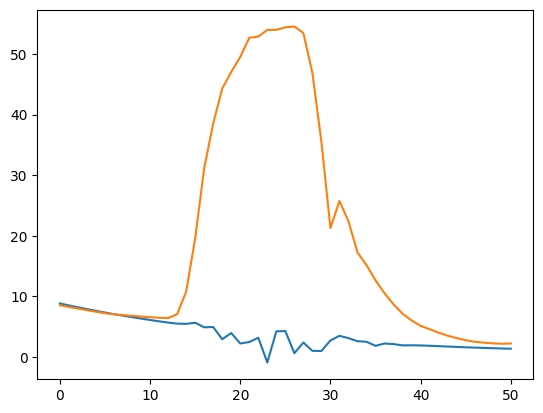

In [7]:
plt.plot(p_rpa_outlet[:,1]/1333.22)
plt.plot(p_rpa_inlet[:,1]/1333.22)
print(np.mean(p_rpa_inlet[:,1]/1333.22))

In [5]:
np.shape(np.vstack((p_valve_dia_outlet[:11,:],p_valve_dia_outlet[28:50,:])))

(33, 3)

In [6]:
vessels = {
    "lv": (p_lv_outlet, p_lv_inlet, 2.1047),
    "rv": (p_rv_outlet, p_rv_inlet, 4.1893),
    "truncus_upstream": (p_truncus_upstream_outlet, p_truncus_upstream_inlet, 6.294),
    "truncus_downstream": (p_truncus_downstream_outlet, p_truncus_downstream_inlet, 6.294),
    "valve_sys": (p_valve_sys_outlet[8:30,:], p_valve_sys_inlet[8:30,:], 7.6538),
    "valve_dia": (np.vstack((p_valve_dia_outlet[:8,:],p_valve_dia_outlet[30:50,:])), np.vstack((p_valve_dia_inlet[:8,:],p_valve_dia_inlet[30:50,:])), -0.4739),
    "aorta": (p_aorta_outlet, p_aorta_inlet, 1.4430),
    "rpa":   (p_rpa_outlet,   p_rpa_inlet,   2.3641),
    "lpa":   (p_lpa_outlet,   p_lpa_inlet,   2.4873),
}

results = {}
for name, (out, inn, qmean) in vessels.items():
    pdiff = out[:, 1] - inn[:, 1]                 
    pdiff_mean = np.mean(pdiff)                
    r = np.abs(pdiff_mean / qmean)
    results[name] = {"pdiff": pdiff, "pdiff_mean": pdiff_mean, "r": r}

# print resistances
for name in ("lv", "rv", "truncus_upstream", "truncus_downstream", "valve_sys", "valve_dia", "aorta", "rpa", "lpa"):
    print(f"r_{name} = {results[name]['r']}")
    print(f"p_{name} = {results[name]['pdiff_mean']}")

r_lv = 82.78158034725273
p_lv = -174.2303921568628
r_rv = 40.4572245913141
p_rv = -169.48745098039217
r_truncus_upstream = 52.12873137815663
p_truncus_upstream = -328.0982352941178
r_truncus_downstream = 11.656604173286755
p_truncus_downstream = 73.36666666666683
r_valve_sys = 302.55618718212463
p_valve_sys = -2315.7045454545455
r_valve_dia = 18630.658216019052
p_valve_dia = 8829.068928571429
r_aorta = 227.29199788023314
p_aorta = 327.98235294117643
r_rpa = 8763.635127076508
p_rpa = -20718.109803921572
r_lpa = 6252.626085612954
p_lpa = -15552.1568627451
